In [ ]:
! pip install -q rank_bm25 datasets spacy ir_measures
! python -m spacy download ru_core_news_sm

In [2]:
from datasets import load_dataset
from math import log
from collections import Counter, defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import time, random
import os
import re

from nltk.stem import PorterStemmer
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from rank_bm25 import BM25Okapi

import ir_measures
from ir_measures import P, MAP, nDCG, read_trec_run, iter_calc
from scipy.stats import zscore, spearmanr, wilcoxon

import xml.etree.ElementTree as ET
import zipfile

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

from sklearn.metrics.pairwise import cosine_similarity
import scipy.sparse as sp

# Дополнительное задание 1: MIRAGE

In [3]:
mirage_ds = load_dataset('nlpai-lab/mirage', split='train')
print(f'Всего строк: {len(mirage_ds)}')
print('Структура MIRAGE:\n', mirage_ds)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/35.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7560 [00:00<?, ? examples/s]

Всего строк: 7560
Структура MIRAGE:
 Dataset({
    features: ['source', 'query_id', 'query', 'doc_name', 'answer', 'doc_url', 'num_doc_labels', 'doc_pool', 'oracle'],
    num_rows: 7560
})


## Сборка qrels
У MIRAGE qrels в trec-формате нет (хотя есть датасет MIRACL), поэтому построим сами:
- rel=1: oracle-passage
- rel=0: остальные четыре passage в пуле (не пишем их в qrels)

In [4]:
mirage_corpus = {}
for row in mirage_ds:
    for mid, chunk in zip(row['doc_pool']['mapped_id'],
                          row['doc_pool']['doc_chunk']):
        if mid not in mirage_corpus:
            mirage_corpus[mid] = chunk

mirage_doc_ids   = list(mirage_corpus.keys())
mirage_doc_texts = [mirage_corpus[d] for d in mirage_doc_ids]

print(f'Уникальных пассажей: {len(mirage_doc_ids):,}')
print(f'Пример пассажа: {mirage_doc_texts[0][:200]}')

Уникальных пассажей: 7,560
Пример пассажа: Scottish printer, journalist and poet
John Mayne (1759–1836) was a Scottish printer, journalist and poet born in Dumfries. In 1780, his poem "The Siller Gun" appeared in its original form in "Ruddiman


In [5]:
mirage_qrels = defaultdict(dict)   # {qid: {doc_id: rel}}
mirage_queries = []                # [(qid, query_text, source)]

for row in mirage_ds:
    qid    = row['query_id']
    oracle = row['oracle']['mapped_id']
    mirage_qrels[qid][oracle] = 1
    mirage_queries.append((qid, row['query'], row['source']))

mirage_qrels = dict(mirage_qrels)
mirage_q_df  = pd.DataFrame(mirage_queries, columns=['doc_id', 'text', 'source'])

print(f'Запросов: {len(mirage_q_df):,}')
print(f'qrels-ключей: {len(mirage_qrels):,}')
print(f'rel-пар суммарно: {sum(len(v) for v in mirage_qrels.values()):,}')

Запросов: 7,560
qrels-ключей: 7,560
rel-пар суммарно: 7,560


## 1.1. Базовая статистика по запросам MIRAGE

In [6]:
def tok(s):
    return [t for t in s.split() if any(c.isalnum() for c in t)]

,value
# queries,7560
avg query length (tokens),8.74
median query length,8
min query length,3
max query length,54
# relevant per query,1 (всегда ровно один oracle)
pool size per query,5
unique passages in corpus,7560


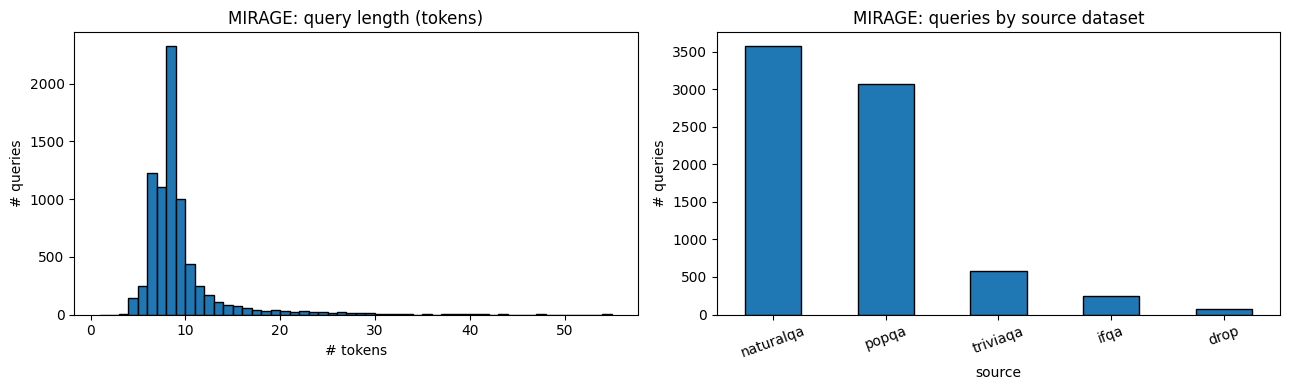

In [7]:
mirage_q_lens = mirage_q_df['text'].astype(str).map(lambda s: len(tok(s)))
rel_per_q_mirage = pd.Series({qid: len(docs) for qid, docs in mirage_qrels.items()})

stats_mirage = {
    '# queries':                    len(mirage_q_df),
    'avg query length (tokens)':    round(mirage_q_lens.mean(), 2),
    'median query length':          int(mirage_q_lens.median()),
    'min query length':             int(mirage_q_lens.min()),
    'max query length':             int(mirage_q_lens.max()),
    '# relevant per query':         '1 (всегда ровно один oracle)',
    'pool size per query':          5,
    'unique passages in corpus':    len(mirage_doc_ids),
}
display(pd.Series(stats_mirage).to_frame('value'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(mirage_q_lens, bins=range(1, mirage_q_lens.max()+2), edgecolor='black')
axes[0].set_title('MIRAGE: query length (tokens)')
axes[0].set_xlabel('# tokens'); axes[0].set_ylabel('# queries')

mirage_q_df['source'].value_counts().plot(kind='bar', ax=axes[1], edgecolor='black')
axes[1].set_title('MIRAGE: queries by source dataset')
axes[1].set_xlabel('source'); axes[1].set_ylabel('# queries')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout(); plt.show()

- 7560 запросов, по одному oracle-passage на каждый, как следствие - метрики типа P@10/P@20 заведомо ограничены сверху значениями 0.1 и 0.05 (один релевантный документ из 10/20)
- средняя длина запроса — 8.7 токенов, медиана 8. Запросы представлены в виде вопросов, а не в качестве ключевых слов как в WikIR. Длина распределена с правым хвостом до 54 токенов.
- Корпус не сбалансирован по источникам, больше всего запросов из popqa и naturalqa 

## 1.2. Обработка коллекции (токенизация, стемминг, лемматизация)

In [8]:
def prepare_queries(q_df, name_prefix):
    qids = q_df['doc_id'].astype(str).tolist()
    texts = q_df['text'].astype(str).tolist()
    raw = [tok(t) for t in texts]
    stm = [stem_tokens(q) for q in raw]
    lem = list(lemma_pipe(texts))
    for var_name, qs in [('raw', raw), ('stem', stm), ('lemma', lem)]:
        empty = [qid for qid, q in zip(qids, qs) if not q]
        if empty:
            print(f'[{name_prefix}/{var_name}] empty queries: {empty}')
    return qids, {'raw': raw, 'stem': stm, 'lemma': lem}

In [9]:
stemmer = PorterStemmer()
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
_stem_cache = {}

def tok(s):
    return [t.lower() for t in s.split() if any(c.isalnum() for c in t)]

def stem_tokens(toks):
    out = []
    for t in toks:
        s = _stem_cache.get(t)
        if s is None:
            s = stemmer.stem(t); _stem_cache[t] = s
        out.append(s)
    return out

def lemma_pipe(texts, batch=512, n_process=1):
    for doc in nlp.pipe(texts, batch_size=batch, n_process=n_process):
        yield [t.lemma_.lower() for t in doc if any(c.isalnum() for c in t.text)]

In [10]:
mirage_qids  = mirage_q_df['doc_id'].tolist()

print('Tokenize docs raw...')
mirage_docs_raw = [tok(t) for t in tqdm(mirage_doc_texts)]

print('Stem docs...')
mirage_docs_stem = [stem_tokens(d) for d in tqdm(mirage_docs_raw)]

print('Lemmatize docs (spaCy)...')
mirage_docs_lemma = list(tqdm(lemma_pipe(mirage_doc_texts), total=len(mirage_doc_texts)))

print('Prepare queries...')
mirage_qids, mirage_q_variants = prepare_queries(mirage_q_df, 'mirage')

print(f'docs: raw={len(mirage_docs_raw)}, stem={len(mirage_docs_stem)}, lemma={len(mirage_docs_lemma)}')

Tokenize docs raw...


  0%|          | 0/7560 [00:00<?, ?it/s]

Stem docs...


  0%|          | 0/7560 [00:00<?, ?it/s]

Lemmatize docs (spaCy)...


  0%|          | 0/7560 [00:00<?, ?it/s]

Prepare queries...
docs: raw=7560, stem=7560, lemma=7560


## 1.3. Построение индексов и прогон tf-idf + BM25

In [11]:
! mkdir -p /kaggle/working/runs_mirage

In [12]:
TOP_K = 1000

def build_tfidf(docs_tokens):
    vec = TfidfVectorizer(
        analyzer=lambda x: x,
        preprocessor=lambda x: x,
        lowercase=False,
        token_pattern=None,
    )
    X = vec.fit_transform(docs_tokens)
    X = normalize(X, norm='l2', axis=1)
    return vec, X

def tfidf_search(vec, X_norm, q_tokens_list, qids, doc_ids, top_k=TOP_K):
    Q = vec.transform(q_tokens_list)
    Q = normalize(Q, norm='l2', axis=1)
    run = {}
    for j, qid in enumerate(qids):
        s = (X_norm @ Q[j].T).toarray().ravel()
        if top_k < len(s):
            idx = np.argpartition(-s, top_k)[:top_k]
            idx = idx[np.argsort(-s[idx])]
        else:
            idx = np.argsort(-s)
        run[qid] = [(doc_ids[i], float(s[i])) for i in idx if s[i] > 0]
    return run

In [13]:
def build_bm25(docs_tokens, k1=1.5, b=0.75):
    return BM25Okapi(docs_tokens, k1=k1, b=b)

def bm25_search(bm25, q_tokens_list, qids, doc_ids, top_k=TOP_K):
    run = {}
    for qid, q in zip(qids, q_tokens_list):
        if not q:
            run[qid] = []
            continue
        scores = bm25.get_scores(q)
        if top_k < len(scores):
            idx = np.argpartition(-scores, top_k)[:top_k]
            idx = idx[np.argsort(-scores[idx])]
        else:
            idx = np.argsort(-scores)
        run[qid] = [(doc_ids[i], float(scores[i])) for i in idx if scores[i] > 0]
    return run

In [14]:
def write_run(run, path, tag='run'):
    with open(path, 'w') as f:
        for qid, results in run.items():
            for rank, (docid, score) in enumerate(results, 1):
                f.write(f'{qid} Q0 {docid} {rank} {score:.6f} {tag}\n')

In [15]:
MIRAGE_VARIANTS = {
    'raw':   mirage_docs_raw,
    'stem':  mirage_docs_stem,
    'lemma': mirage_docs_lemma,
}
mirage_runs_dir = '/kaggle/working/runs_mirage'
mirage_runs     = {}
mirage_build_times  = {}
mirage_search_times = {}

for name, docs in MIRAGE_VARIANTS.items():
    t0 = time.time()
    tfidf_idx = build_tfidf(docs)
    t1 = time.time()
    bm25_idx  = build_bm25(docs)
    t2 = time.time()
    mirage_build_times[name] = {
        'tfidf_build_s': round(t1 - t0, 2),
        'bm25_build_s':  round(t2 - t1, 2),
    }

    vec, X = tfidf_idx
    q = mirage_q_variants[name]

    t3 = time.time()
    mirage_runs[f'tfidf_{name}'] = tfidf_search(vec, X, q, mirage_qids, mirage_doc_ids)
    t4 = time.time()
    mirage_runs[f'bm25_{name}']  = bm25_search(bm25_idx, q, mirage_qids, mirage_doc_ids)
    t5 = time.time()

    mirage_search_times[f'tfidf_{name}'] = round(t4 - t3, 2)
    mirage_search_times[f'bm25_{name}']  = round(t5 - t4, 2)
    print(f'{name}: tfidf={t4-t3:.1f}s, bm25={t5-t4:.1f}s')

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:523: UserWarning: The parameter 'preprocessor' will not be used since 'analyzer' is callable'
  warnings.warn(


raw: tfidf=35.8s, bm25=137.6s
stem: tfidf=34.6s, bm25=109.8s
lemma: tfidf=30.7s, bm25=140.8s


In [16]:
for tag, run in mirage_runs.items():
    write_run(run, f'{mirage_runs_dir}/{tag}.txt', tag=tag)

rows = []
for tag, t_search in mirage_search_times.items():
    model, variant = tag.split('_', 1)
    rows.append({
        'model':          model,
        'variant':        variant,
        'build_s':        mirage_build_times[variant][f'{model}_build_s'],
        'search_total_s': t_search,
        'per_query_ms':   round(t_search * 1000 / len(mirage_qids), 1),
    })
pd.DataFrame(rows).set_index(['model', 'variant']).sort_index()

build_s  search_total_s  per_query_ms
model variant                                       
bm25  lemma       0.41          140.77          18.6
      raw         0.47          137.59          18.2
      stem        0.41          109.84          14.5
tfidf lemma       0.68           30.68           4.1
      raw         0.96           35.84           4.7
      stem        0.72           34.59           4.6

- TF-IDF в 4 раза быстрее BM25 на поиске
- Стемминг ускоряет BM25: словарь меньше -> меньше операций. На TF-IDF разница нивелируется

## 1.4. Оценка ранов через ir-measures

In [17]:
MIRAGE_MEASURES = [
    P(rel=1) @ 1,
    P(rel=1) @ 10,
    P(rel=1) @ 20,
    MAP(rel=1),
    nDCG(dcg='log2') @ 20,
]
MEASURE_NAMES = ['P@1', 'P@10', 'P@20', 'MAP', 'nDCG@20']

rows = []
for tag in mirage_runs:
    run_path = f'{mirage_runs_dir}/{tag}.txt'
    res = ir_measures.calc_aggregate(
        MIRAGE_MEASURES, mirage_qrels, read_trec_run(str(run_path)))
    rows.append({'run': tag, **{name: res[m]
                                for name, m in zip(MEASURE_NAMES, MIRAGE_MEASURES)}})
mirage_results_df = pd.DataFrame(rows).set_index('run')
display(mirage_results_df.round(4))
mirage_results_df.round(4).to_csv('/kaggle/working/results_mirage.csv')

,P@1,P@10,P@20,MAP,nDCG@20
run,,,,,
tfidf_raw,0.3983,0.0603,0.0322,0.4703,0.5089
bm25_raw,0.4811,0.0616,0.0322,0.5310,0.5558
tfidf_stem,0.3939,0.0599,0.0319,0.4647,0.5034
bm25_stem,0.4839,0.0619,0.0323,0.5326,0.5574
tfidf_lemma,0.5425,0.0811,0.0428,0.6370,0.6866
bm25_lemma,0.6612,0.0832,0.0432,0.7229,0.7546


- BM25 стабильно лучше TF-IDF на всех вариантах препроцессинга
- Стемминг почти не влияет на качество. Porter-стеммер часто в коротких пассажах склеивает слова, которые лучше было бы оставить раздельно.
- Лемматизация даёт огромный прирост: BM25-lemma выигрывает у BM25-raw +0.20 nDCG@20 и +0.18 P@1. Это сильно отличается от WikIR, где морфологическая обработка почти ничего не меняла.

## 1.5. Сравнение WikIR vs MIRAGE
Выводим лучший ран каждой коллекции для сравнения, потом полные таблицы

In [18]:
# результаты из WikiR ноутбука
results_df = pd.DataFrame({'P@1': [0.51, 0.49, 0.50, 0.49, 0.48, 0.48], 
                           'P@10': [0.203, 0.212, 0.194, 0.209, 0.200, 0.210], 
                           'P@20': [0.1350, 0.1500, 0.1285, 0.1455, 0.1300, 0.1480], 
                           'AP': [0.165487, 0.175222, 0.159471, 0.174212, 0.161438, 0.175419],
                           'nDCG@20': [0.349875, 0.356960, 0.335375, 0.354021, 0.339139, 0.356117]}, 
                            index=['tfidf_raw', 'bm25_raw', 'tfidf_stem', 
                                   'bm25_stem', 'tfidf_lemma', 'bm25_lemma'])

Лучший ран WikIR:  bm25_raw
Лучший ран MIRAGE: bm25_lemma


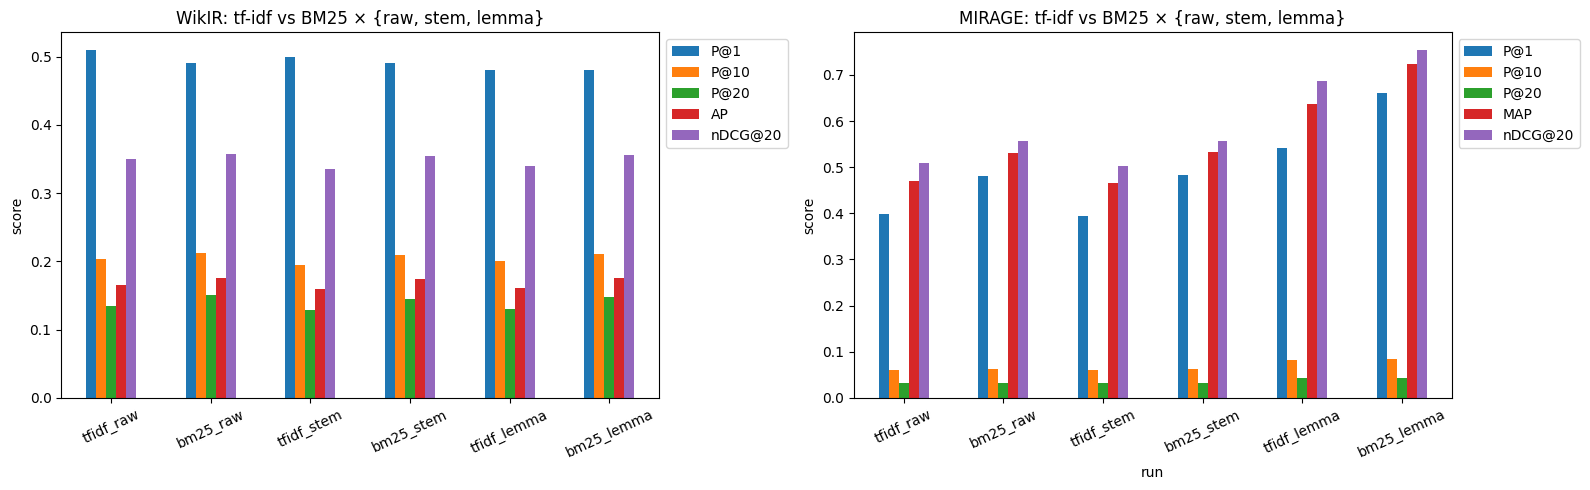

In [19]:
best_wikir  = results_df['nDCG@20'].idxmax()
best_mirage = mirage_results_df['nDCG@20'].idxmax()

print(f'Лучший ран WikIR:  {best_wikir}')
print(f'Лучший ран MIRAGE: {best_mirage}')

compare_df = pd.concat([
    results_df.assign(collection='WikIR'),
    mirage_results_df.assign(collection='MIRAGE'),
]).reset_index().rename(columns={'index': 'run'})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, collection, df_ in [
    (axes[0], 'WikIR',  results_df),
    (axes[1], 'MIRAGE', mirage_results_df),
]:
    df_.plot(kind='bar', ax=ax, rot=25)
    ax.set_title(f'{collection}: tf-idf vs BM25 × {{raw, stem, lemma}}')
    ax.set_ylabel('score')
    ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))
plt.tight_layout(); plt.show()

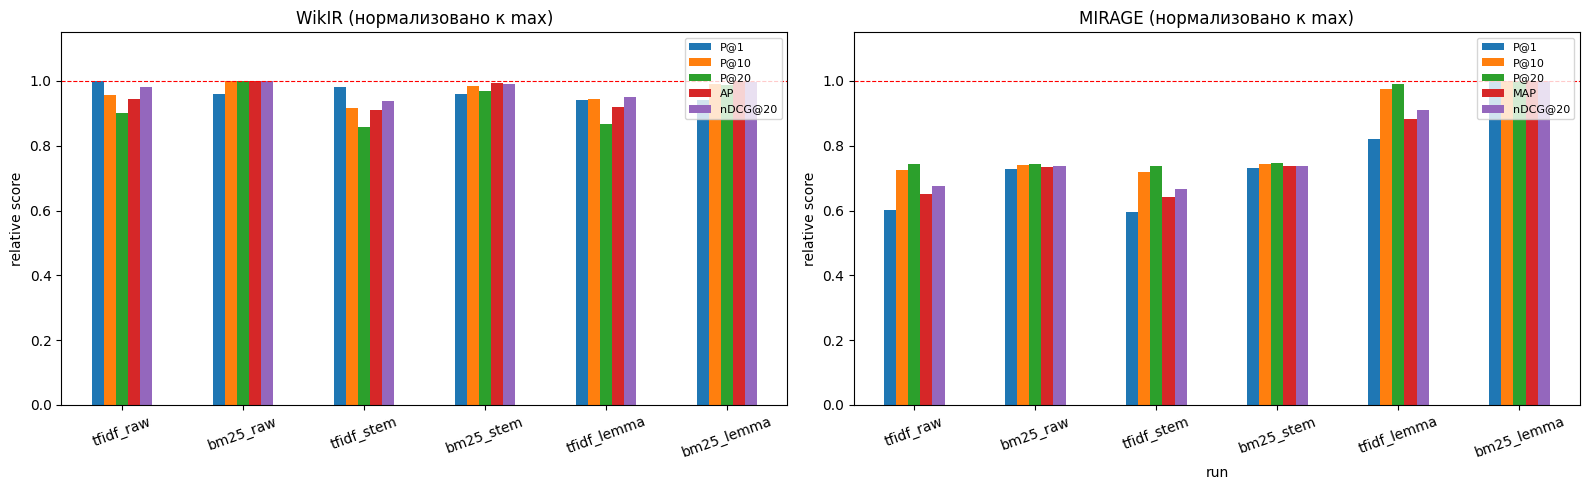

In [20]:
# Нормализованное сравнение
norm_wikir  = results_df / results_df.max()
norm_mirage = mirage_results_df / mirage_results_df.max()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, norm_df, title in [
    (axes[0], norm_wikir,  'WikIR (нормализовано к max)'),
    (axes[1], norm_mirage, 'MIRAGE (нормализовано к max)'),
]:
    norm_df.plot(kind='bar', ax=ax, rot=20)
    ax.set_title(title)
    ax.set_ylabel('relative score')
    ax.set_ylim(0, 1.15)
    ax.axhline(1.0, color='red', lw=0.8, ls='--')
    ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

- На WikIR разница между ранами в пределах 5% — морфология там фактически не работает. На MIRAGE — почти 35%.
- Гипотеза: запросы MIRAGE - естественно сформулированные вопросы с разнообразными словоформами («was the director», «who painted»), а пассажи - повествовательные предложения с теми же словами в других формах. Лемматизация склеивает их в один токен, и точное совпадение начинает работать. На WikIR запросы и документы - это заголовки и абзацы из Википедии, лексика там уже выровнена.

## 1.6. Per-query анализ MIRAGE

In [21]:
MIRAGE_RUN_TAGS = list(mirage_runs.keys())

measure_name_map = dict(zip(MIRAGE_MEASURES, MEASURE_NAMES))

rows = []
for tag in MIRAGE_RUN_TAGS:
    run_path = f'{mirage_runs_dir}/{tag}.txt'
    for r in iter_calc(MIRAGE_MEASURES, mirage_qrels,
                       read_trec_run(str(run_path))):
        rows.append({'qid': r.query_id, 'run': tag,
                     'measure': measure_name_map[r.measure],  # <-- было str(r.measure)
                     'value': r.value})
mirage_big_perq = pd.DataFrame(rows)

qid_source = dict(zip(mirage_q_df['doc_id'], mirage_q_df['source']))
mirage_big_perq['source'] = mirage_big_perq['qid'].map(qid_source)

### 1.6.1. Сложные/легкие запросы

In [22]:
mirage_perq_wide = mirage_big_perq.pivot_table(
    index='qid', columns=['run', 'measure'], values='value')

z_mirage = mirage_perq_wide.apply(zscore, nan_policy='omit')
difficulty_mirage = z_mirage.mean(axis=1).sort_values()

mirage_qtext_map = dict(zip(mirage_q_df['doc_id'], mirage_q_df['text']))
mirage_src_map   = dict(zip(mirage_q_df['doc_id'], mirage_q_df['source']))

print('=== Hard запросы MIRAGE (топ-10) ===')
print(f'{"qid":>12}  {"diff_z":>6}  {"source":>10}  query')
for qid in difficulty_mirage.head(10).index:
    print(f'{str(qid):>12}  {difficulty_mirage[qid]:+.2f}  '
          f'{mirage_src_map.get(qid, "?"):>10}  '
          f'{mirage_qtext_map.get(qid, "")[:70]}')

print('\n=== Easy запросы MIRAGE (топ-10) ===')
print(f'{"qid":>12}  {"diff_z":>6}  {"source":>10}  query')
for qid in difficulty_mirage.tail(10).index:
    print(f'{str(qid):>12}  {difficulty_mirage[qid]:+.2f}  '
          f'{mirage_src_map.get(qid, "?"):>10}  '
          f'{mirage_qtext_map.get(qid, "")[:70]}')

=== Hard запросы MIRAGE (топ-10) ===
         qid  diff_z      source  query
ffe67eee-12f1-4e03-b356-3b3dcbe9e258  -1.40       popqa  What genre is Stranger?
fed71452-d123-487c-a454-10e12966c980  -1.40        drop  Who was 1-0
0085a069-c8c1-4a78-9074-0f17d2073f9c  -1.40       popqa  Who was the director of Home?
4642589d-ede5-4e6c-85fe-f89535246145  -1.40       popqa  Who was the director of Out to Win?
d92f2d01-a15d-4593-ad70-ee79290e0f24  -1.40       popqa  Who is the author of ?
46dbacda-cc8a-4ec3-89b7-84f2c79bf55e  -1.40       popqa  Who is the author of Stations?
5b5bc971-e349-48fc-8625-d878dc723db4  -1.40       popqa  Who is the author of Before?
18362389-defa-43cf-b93c-29bb83843069  -1.40   naturalqa  what do you mean by the term dewani
cc17337b-0eff-4d49-86a1-6478f97d1f18  -1.40       popqa  Who was the director of Album?
ca703755-84a6-498b-9603-6212a70bf30f  -1.40       popqa  Who was the director of The Hard Way?

=== Easy запросы MIRAGE (топ-10) ===
         qid  diff_z     

Сложные запросы (diff_z = −1.40 у всех 10):
- У всех одинаковое значение −1.40 - значит, эти запросы провалились сразу во всех 6 ранах.
- 8 из 10 — из popqa и построены по шаблону `"Who was the director/author of X?"`, где X — короткое общеупотребительное слово: *Home*, *Stranger*, *Album*, *Before*. По таким словам в корпусе слишком много документов, и модель не понимает, какой именно нужен.
- Один запрос вообще пустой: `"Who is the author of ?"` — это ошибка в данных.

Лёгкие запросы (diff_z = +0.86 у всех 10):
- Одинаковое значение +0.86 — это потолок: правильный документ стоит на первом месте во всех ранах.
- Все запросы длинные и содержат конкретные имена и названия: *Motorola E4 Plus*, *Earl Grey*, *Rachel Maddow*, *República de Yucatán*. Такие сочетания слов встречаются ровно в одном документе на весь корпус, поэтому модель легко его находит.
- 8 из 10 — из naturalqa, где вопросы сформулированы естественно и со всеми деталями.

### 1.6.2. Влияние свойств запроса

In [25]:
N_mirage = len(mirage_docs_raw)
mirage_df_counter = Counter()
for d in mirage_docs_raw:
    for t in set(d):
        mirage_df_counter[t] += 1

def mirage_term_idf(t):
    return log(N_mirage / (1 + mirage_df_counter.get(t, 0)))

mirage_q_tokens_raw = mirage_q_variants['raw']
mirage_q_props = pd.DataFrame({
    'qid':     mirage_qids,
    'length':  [len(q) for q in mirage_q_tokens_raw],
    'avg_idf': [np.mean([mirage_term_idf(t) for t in q]) if q else 0 for q in mirage_q_tokens_raw],
    'max_idf': [max([mirage_term_idf(t) for t in q]) if q else 0 for q in mirage_q_tokens_raw],
    'min_idf': [min([mirage_term_idf(t) for t in q]) if q else 0 for q in mirage_q_tokens_raw],
}).set_index('qid')

# Средние метрики по запросу усредняем по всем ранам
mirage_mean_by_measure = (
    mirage_big_perq
    .groupby(['qid', 'measure'])['value']
    .mean()
    .unstack()
)[MEASURE_NAMES]

corr_rows = []
for prop in ['length', 'avg_idf', 'max_idf', 'min_idf']:
    row = {'property': prop}
    for m in MEASURE_NAMES:
        common = mirage_q_props.index.intersection(mirage_mean_by_measure.index)
        rho, p = spearmanr(mirage_q_props.loc[common, prop],
                           mirage_mean_by_measure.loc[common, m])
        row[m] = f'{rho:+.2f}{"*" if p < 0.05 else ""}{"*" if p < 0.01 else ""}'
    corr_rows.append(row)

corr_df_mirage = pd.DataFrame(corr_rows).set_index('property')
print('Spearman ρ (query property × metric, mean across 6 runs)')
print('* = p<0.05, ** = p<0.01')
display(corr_df_mirage)

Spearman ρ (query property × metric, mean across 6 runs)
* = p<0.05, ** = p<0.01


,P@1,P@10,P@20,MAP,nDCG@20
property,,,,,
length,+0.36**,+0.44**,+0.45**,+0.39**,+0.40**
avg_idf,+0.41**,+0.41**,+0.41**,+0.43**,+0.43**
max_idf,-0.25**,-0.34**,-0.36**,-0.28**,-0.29**
min_idf,+0.19**,+0.19**,+0.20**,+0.20**,+0.20**


- Длина запроса коррелирует положительно (ρ ≈ +0.4): чем длиннее вопрос, тем больше «зацепок» для метча. Это противоположно ожиданию — обычно длинные запросы сложнее.
- avg_idf положительно коррелирует с качеством (+0.4): редкая лексика — это конкретные имена/названия, которые однозначно идентифицируют ответ.
- max_idf отрицательно коррелирует (−0.3). Парадокс на первый взгляд, но объяснимо: max_idf высок для опечаток, редких имён собственных, которых нет в oracle-пассаже под этой формой
- min_idf положительно (+0.2): отсутствие частотного мусора в запросе помогает.

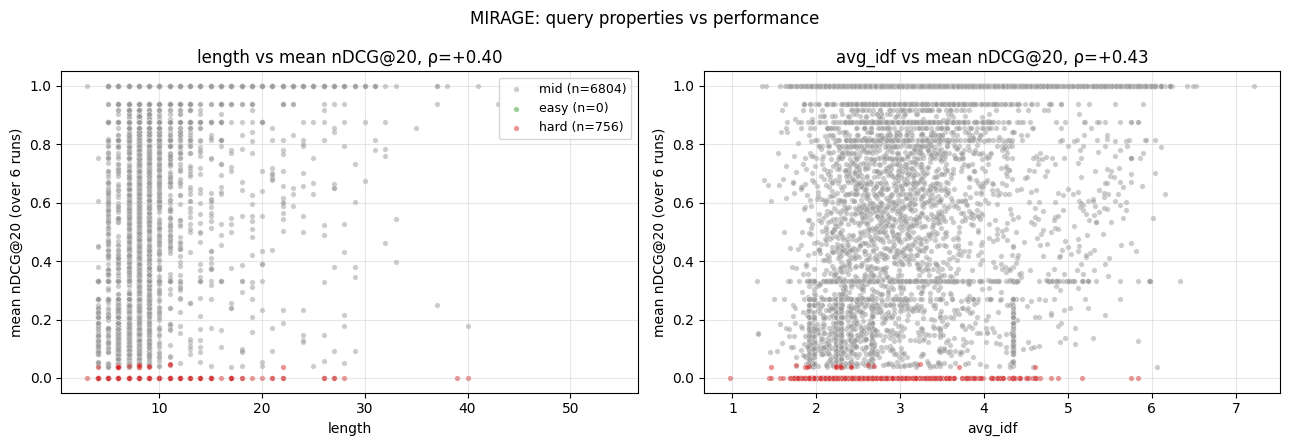

In [26]:
# Визуализация: length и avg_idf vs mean nDCG@20, раскрашено по hard/easy
mirage_perq_wide = mirage_big_perq.pivot_table(
    index='qid', columns=['run', 'measure'], values='value')
z_mirage = mirage_perq_wide.apply(zscore, nan_policy='omit')
difficulty_mirage = z_mirage.mean(axis=1).sort_values()

diff_cat_mirage = pd.cut(
    difficulty_mirage,
    bins=[-np.inf, difficulty_mirage.quantile(0.1),
          difficulty_mirage.quantile(0.9), np.inf],
    labels=['hard', 'mid', 'easy']
)
colors_map = {'hard': '#d62728', 'mid': '#999999', 'easy': '#2ca02c'}

ndcg_mean_mirage = mirage_mean_by_measure['nDCG@20']
common = (mirage_q_props.index
          .intersection(ndcg_mean_mirage.index)
          .intersection(diff_cat_mirage.index))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, prop in zip(axes, ['length', 'avg_idf']):
    for c in ['mid', 'easy', 'hard']:
        mask_idx = [i for i in common if diff_cat_mirage.loc[i] == c]
        ax.scatter(mirage_q_props.loc[mask_idx, prop],
                   ndcg_mean_mirage.loc[mask_idx],
                   c=colors_map[c], alpha=0.5, s=15,
                   edgecolors='white', linewidths=0.3,
                   label=f'{c} (n={len(mask_idx)})')
    rho, p = spearmanr(mirage_q_props.loc[common, prop],
                       ndcg_mean_mirage.loc[common])
    ax.set_xlabel(prop)
    ax.set_ylabel('mean nDCG@20 (over 6 runs)')
    ax.set_title(f'{prop} vs mean nDCG@20, ρ={rho:+.2f}')
    ax.grid(alpha=0.3)
axes[0].legend(loc='upper right', fontsize=9)
plt.suptitle('MIRAGE: query properties vs performance')
plt.tight_layout()
plt.show()

Длина запроса (слева):
- Точки группируются вертикальными полосками по целочисленным значениям длины
- Видно, что короткие запросы (3-6 токенов) занимают весь диапазон от 0 до 1: среди них есть и удачные, и провальные. А вот длинных провалов почти нет — красные точки концентрируются слева, в зоне коротких запросов.

Средний IDF (справа):
- Корреляция ρ=+0.43 — статистически значимая и заметная глазу.
- Красные точки (hard) расположены не равномерно: они «выпали в осадок» на нижней границе, причём в основном при низком и среднем avg_idf (1.5-4). Это и есть те самые popqa-запросы про «Home», «Album» - короткие частые слова дают низкий средний IDF.
- Сверху видна полоса точек на уровне 1.0 — запросы с высоким avg_idf там встречаются чаще.


nDCG@20 по source × run:


run,bm25_lemma,bm25_raw,bm25_stem,tfidf_lemma,tfidf_raw,tfidf_stem
source,,,,,,
drop,0.399,0.266,0.303,0.342,0.234,0.245
ifqa,0.757,0.685,0.681,0.752,0.678,0.676
naturalqa,0.856,0.764,0.769,0.756,0.681,0.678
popqa,0.615,0.279,0.276,0.576,0.275,0.267
triviaqa,0.914,0.723,0.726,0.859,0.649,0.643


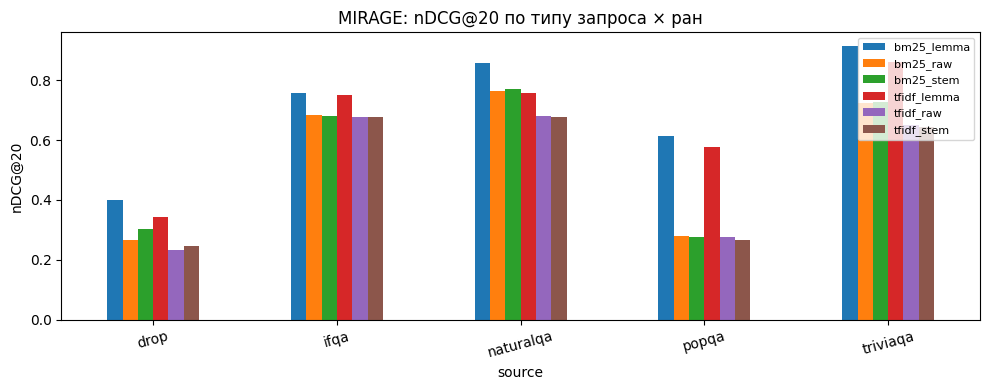

In [27]:
ndcg_by_source = (
    mirage_big_perq
    .query('measure == "nDCG@20"')
    .groupby(['source', 'run'])['value']
    .mean()
    .unstack('run')
    .round(3)
)
print('nDCG@20 по source × run:')
display(ndcg_by_source)

ndcg_by_source.plot(kind='bar', figsize=(10, 4), rot=15)
plt.title('MIRAGE: nDCG@20 по типу запроса × ран')
plt.ylabel('nDCG@20')
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

- naturalqa и triviaqa дают nDCG@20 ≈ 0.85–0.91 на bm25_lemma — это очень высоко.
- popqa и drop проседают сильнее всех. popqa — это шаблонные вопросы вида «Who was the director of X?», где X — короткое неоднозначное название («Highway», «Stop», «Album»), которое матчится с десятками не относящихся к делу документов.
- drop — вопросы с числовыми/арифметическими ответами, лексическая модель в принципе на них плохо работает.

### 1.6.3. Влияние морфологии на MIRAGE

Таблица метрик MIRAGE (все раны):


,P@1,P@10,P@20,MAP,nDCG@20
run,,,,,
tfidf_raw,0.3983,0.0603,0.0322,0.4703,0.5089
bm25_raw,0.4811,0.0616,0.0322,0.5310,0.5558
tfidf_stem,0.3939,0.0599,0.0319,0.4647,0.5034
bm25_stem,0.4839,0.0619,0.0323,0.5326,0.5574
tfidf_lemma,0.5425,0.0811,0.0428,0.6370,0.6866
bm25_lemma,0.6612,0.0832,0.0432,0.7229,0.7546



Δ (bm25_raw − bm25_stem):


,P@1,P@10,P@20,MAP,nDCG@20
delta,-0.0028,-0.0002,-0.0001,-0.0016,-0.0016


Δ (bm25_raw − bm25_lemma):


,P@1,P@10,P@20,MAP,nDCG@20
delta,-0.1802,-0.0216,-0.011,-0.1919,-0.1988


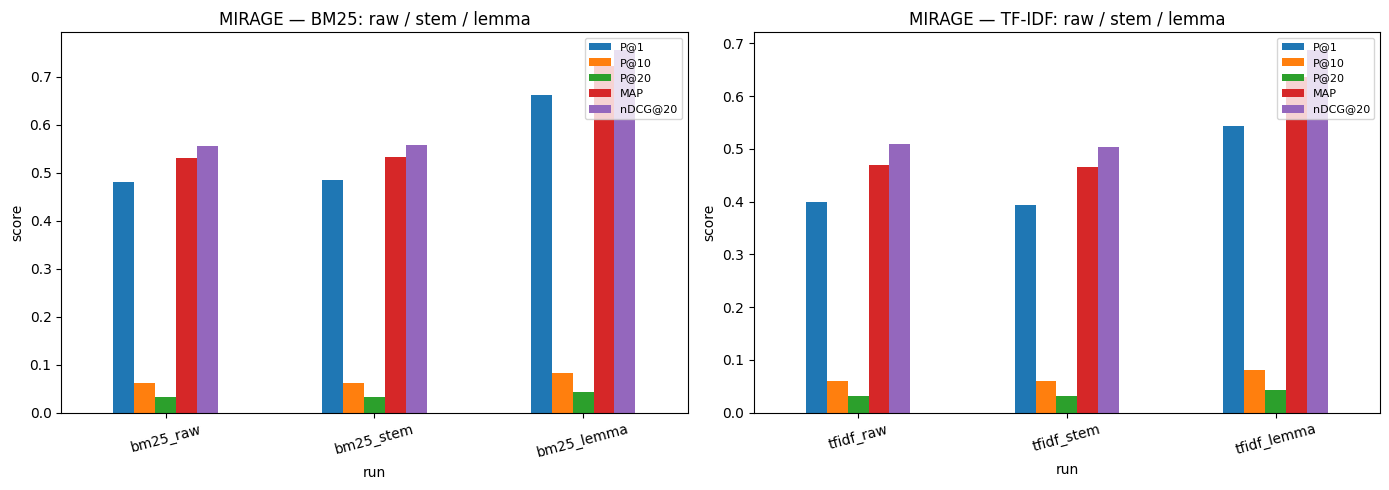

In [28]:
print('Таблица метрик MIRAGE (все раны):')
display(mirage_results_df.round(4))

delta_stem  = mirage_results_df.loc['bm25_raw'] - mirage_results_df.loc['bm25_stem']
delta_lemma = mirage_results_df.loc['bm25_raw'] - mirage_results_df.loc['bm25_lemma']

print('\nΔ (bm25_raw − bm25_stem):')
display(delta_stem.to_frame('delta').T.round(4))
print('Δ (bm25_raw − bm25_lemma):')
display(delta_lemma.to_frame('delta').T.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, prefix, title in [
    (axes[0], 'bm25',  'BM25: raw / stem / lemma'),
    (axes[1], 'tfidf', 'TF-IDF: raw / stem / lemma'),
]:
    sub = mirage_results_df.loc[
        [idx for idx in mirage_results_df.index if idx.startswith(prefix)]
    ]
    sub.plot(kind='bar', ax=ax, rot=15)
    ax.set_title(f'MIRAGE — {title}')
    ax.set_ylabel('score')
    ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

- Стемминг почти ничего не даёт (Δ (bm25_raw − bm25_stem) ≈ −0.002 по всем метрикам, то есть стемминг чуть-чуть улучшает результат, но разница в пределах шума)
- Лемматизация даёт огромный прирост. Δ (bm25_raw − bm25_lemma) ≈ −0.19 по nDCG@20 и MAP, −0.18 по P@1. 


- Запросы — естественные вопросы (NaturalQuestions, TriviaQA), где глаголы стоят в личных формах: «who **painted**», «when **did** ... come out», «where **is** ... broadcast». В пассажах те же события описаны в других формах: «**painting**», «**released**», «**broadcasts from**».
- Без лемматизации эти формы — разные токены, и точного совпадения нет. Лемматизация склеивает их в один, и мэтч появляется.
- На WikIR этого эффекта нет, потому что запросы там — короткие ключевые слова без личных форм глагола, и склеивать почти нечего.

### 1.6.4. Корреляция метрик per-query

Spearman-корреляция метрик (лучший ран MIRAGE):


measure,MAP,P@1,P@10,P@20,nDCG@20
measure,,,,,
MAP,1.000,0.973,0.768,0.703,0.998
P@1,0.973,1.000,0.628,0.552,0.974
P@10,0.768,0.628,1.000,0.880,0.770
P@20,0.703,0.552,0.880,1.000,0.704
nDCG@20,0.998,0.974,0.770,0.704,1.000


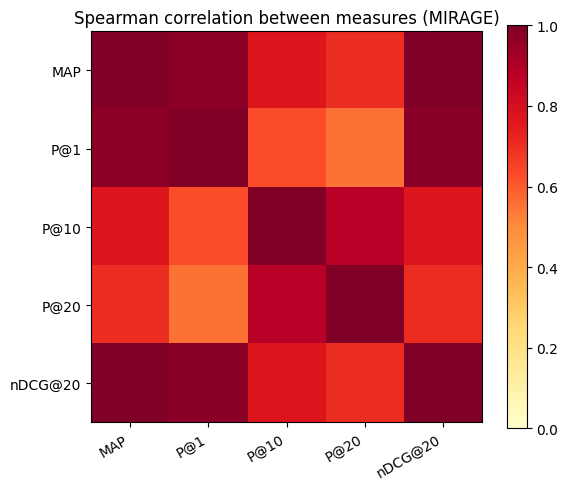

In [29]:
best_mirage_perq = (
    mirage_big_perq
    .query('run == @best_mirage')
    .pivot(index='qid', columns='measure', values='value')
)

corr_mirage = best_mirage_perq.corr(method='spearman')
print('Spearman-корреляция метрик (лучший ран MIRAGE):')
display(corr_mirage.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_mirage.values, vmin=0, vmax=1, cmap='YlOrRd')
ax.set_xticks(range(len(corr_mirage.columns)))
ax.set_yticks(range(len(corr_mirage.columns)))
ax.set_xticklabels(corr_mirage.columns, rotation=30, ha='right')
ax.set_yticklabels(corr_mirage.columns)
plt.colorbar(im, ax=ax)
ax.set_title('Spearman correlation between measures (MIRAGE)')
plt.tight_layout()
plt.show()

- nDCG@20 и MAP коррелируют почти идеально (ρ=0.998) — на этой коллекции они взаимозаменяемы
- P@1 коррелирует с MAP/nDCG (~0.97) — для коллекции с одним релевантымм запросом top-1 точность равна успеху.
- P@10 и P@20 имеют более низкую корреляцию (~0.55–0.88) с rank-aware метриками: они одинаково считают успехом и top-1, и top-10, теряя информацию о позиции.
- Вывод: для этой коллекции достаточно одной из трех метрик (MAP, nDCG@20, P@1) плюс одна precision-метрика для контроля.

### 1.6.5. Нерелевантные top-1

In [30]:
# Для каждого рана: сколько запросов имеют top-1 вне qrels?
top1_stats_mirage = []
for tag in MIRAGE_RUN_TAGS:
    n_outside = 0
    for qid, results in mirage_runs[tag].items():
        if not results:
            continue
        top_doc = results[0][0]
        if top_doc not in mirage_qrels.get(str(qid), {}):
            n_outside += 1
    top1_stats_mirage.append({'run': tag, 'top1 outside qrels': n_outside,
                               'pct': f'{n_outside / len(mirage_runs[tag]) * 100:.1f}%'})

top1_mirage_df = pd.DataFrame(top1_stats_mirage).set_index('run')
display(top1_mirage_df)

# Пересечение: в каких запросах все раны ошибаются на top-1
top1_outside_by_run = {}
for tag in MIRAGE_RUN_TAGS:
    s = set()
    for qid, results in mirage_runs[tag].items():
        if results and results[0][0] not in mirage_qrels.get(str(qid), {}):
            s.add(str(qid))
    top1_outside_by_run[tag] = s

intersection_mirage = set.intersection(*top1_outside_by_run.values())
union_mirage = set.union(*top1_outside_by_run.values())
print(f'\nTop-1 вне qrels во ВСЕХ ранах: {len(intersection_mirage)} '
      f'({len(intersection_mirage)/len(mirage_qids)*100:.1f}%)')
print(f'Top-1 вне qrels хотя бы в одном ране: {len(union_mirage)} '
      f'({len(union_mirage)/len(mirage_qids)*100:.1f}%)')

,top1 outside qrels,pct
run,,
tfidf_raw,4546,60.1%
bm25_raw,3919,51.8%
tfidf_stem,4582,60.6%
bm25_stem,3903,51.6%
tfidf_lemma,3460,45.8%
bm25_lemma,2564,33.9%



Top-1 вне qrels во ВСЕХ ранах: 2068 (27.4%)
Top-1 вне qrels хотя бы в одном ране: 5155 (68.2%)


Даже на лучшем ране bm25_lemma 34% запросов имеют top-1 вне qrels. Qrels содержит ровно один правильный ответ для каждого запроса, и любой другой релевантный документ автоматически объявляется нерелевантным. 27% запросов топ-1 нерелеватный во всех 6 ранах — это и есть сложные запросы

In [32]:
# Детальный разбор для лучшего рана
random.seed(42)
hard_sample = random.sample(list(intersection_mirage), min(5, len(intersection_mirage)))

print(f'Детальный разбор для {best_mirage} (запросы, где top-1 вне qrels во ВСЕХ ранах):\n')
for qid in hard_sample:
    oracle_doc = list(mirage_qrels.get(str(qid), {}).keys())
    oracle_text = mirage_corpus.get(oracle_doc[0], '?') if oracle_doc else '?'
    top3 = mirage_runs[best_mirage].get(str(qid), [])[:3]

    print('-' * 80)
    print(f'Query:  {mirage_qtext_map.get(str(qid), "?")}')
    print(f'Source: {mirage_src_map.get(str(qid), "?")}')
    print(f'Oracle: {oracle_text[:200]}')
    print('Top-3 в ране:')
    for rank, (docid, score) in enumerate(top3, 1):
        is_oracle = '✓ ORACLE' if docid in oracle_doc else '✗'
        print(f'  [{rank}] {is_oracle} score={score:.3f}  '
              f'{mirage_corpus.get(docid, "")[:150]}')
    print()

Детальный разбор для bm25_lemma (запросы, где top-1 вне qrels во ВСЕХ ранах):

--------------------------------------------------------------------------------
Query:  Who was the producer of Highway?
Source: popqa
Oracle: Highway is a 1995 Indian Malayalam-language action thriller film directed by Jayaraaj, produced by Prem Prakash, and written by Sab John. The film stars Suresh Gopi and Bhanupriya, with Vijayaraghavan
Top-3 в ране:
  [1] ✗ score=24.046  Historic long-distance highway in the United States
The Lincoln Highway is one of the first transcontinental highways in the United States and one of 
  [2] ✗ score=22.528  1980 studio album by AC/DC
Back in Black is the seventh studio album by Australian rock band AC/DC, released on 25 July 1980, by Albert Productions an
  [3] ✗ score=22.312  Tunnel in Arkansas
The Bobby Hopper Tunnel is a highway tunnel on Interstate 49 (I-49) in Arkansas, just north of the Crawford—Washington county line.

------------------------------------------

Во всех случаях это вопрос из popqa, и в качестве X выступает общее слово, которое приятягивает не совсем релевантные документы. Например: "Who was the producer of Highway?" — слово "Highway" слишком общее, BM25 поднимает «Lincoln Highway» (highway×2) выше документа про этот фильм, где слово "Highway" встречается один раз. 

## 1.7. Подбор k1 и b для MIRAGE

MIRAGE не содержит валидационного подмножества, поэтому корректный grid search
по гиперпараметрам BM25 невозможен без утечки тестовых данных.
Вместо этого применяем параметры, найденные на WikIR (k1=best_k1, b=best_b),
и сравниваем с дефолтными (k1=1.5, b=0.75) на тестовом наборе MIRAGE:

In [35]:
def format_run(run):
    out = {}
    for qid, results in run.items():
        out_results = {}
        for docid, score in results:
            out_results[str(docid)] = float(score)
        out[str(qid)] = out_results
    return out

In [36]:
best_k1, best_b =0.6, 0.0
bm25_tuned_mirage = BM25Okapi(mirage_docs_raw, k1=best_k1, b=best_b)
tuned_run_mirage  = bm25_search(bm25_tuned_mirage,
                                mirage_q_variants['raw'],
                                mirage_qids, mirage_doc_ids)

res_default = ir_measures.calc_aggregate(
    MIRAGE_MEASURES, mirage_qrels,
    format_run(mirage_runs['bm25_raw']))

res_tuned = ir_measures.calc_aggregate(
    MIRAGE_MEASURES, mirage_qrels,
    format_run(tuned_run_mirage))

compare = pd.DataFrame({
    'bm25_raw (default k1=1.5, b=0.75)': {n: res_default[m] for n, m in zip(MEASURE_NAMES, MIRAGE_MEASURES)},
    f'bm25_raw (WikIR-tuned k1={best_k1}, b={best_b})': {n: res_tuned[m] for n, m in zip(MEASURE_NAMES, MIRAGE_MEASURES)},
}).T.round(4)
display(compare)

,P@1,P@10,P@20,MAP,nDCG@20
"bm25_raw (default k1=1.5, b=0.75)",0.4811,0.0616,0.0322,0.5310,0.5558
"bm25_raw (WikIR-tuned k1=0.6, b=0.0)",0.4712,0.0609,0.0319,0.5206,0.5463


- WikIR-оптимальные k1=0.6, b=0.0 на MIRAGE дают небольшое **ухудшение** (~−0.01 nDCG@20, ~−0.01 P@1) по сравнению с дефолтом (на самом деле это потому что и для Wikir эти параметры дали ухудшения на тесте, т.к. произошло переобучение

---
# Дополнительное задание 2: Толстой и Достоевский

## Загрузка и чтение данных

In [3]:
dataset_path = '/kaggle/input/datasets/hemulitch/tolstoy-dostoevsky'
tolstoy_paths  = [f'{dataset_path}/{f}' for f in os.listdir(dataset_path) if f.startswith('tolstoj')]
dost_paths  = [f'{dataset_path}/{f}' for f in os.listdir(dataset_path) if f.startswith('dostoewskij')]

In [4]:
RU_TOKEN = re.compile(r'[а-яёА-ЯЁ]+')
FB2_NS = '{http://www.gribuser.ru/xml/fictionbook/2.1}'

def parse_fb2_paragraphs(path):
    tree = ET.parse(path)
    root = tree.getroot()
    paragraphs = []
    for body in root.findall(f'{FB2_NS}body'):
        if body.get('name') in ('notes', 'comments'):
            continue
        for p in body.iter(f'{FB2_NS}p'):
            text = ''.join(p.itertext()).strip()
            if text:
                paragraphs.append(text)
    return paragraphs

In [5]:
def load_author_paragraphs(fb2_paths):
    all_paras, all_labels = [], []
    for path in fb2_paths:
        book_name = path.split('/')[-1]
        paras = parse_fb2_paragraphs(path)
        print(f'  {book_name}: {len(paras)} абзацев')
        all_paras.extend(paras)
        all_labels.extend([book_name] * len(paras))
    return all_paras, all_labels

print('=== Толстой ===')
tol_paras, tol_labels = load_author_paragraphs(tolstoy_paths)

print('=== Достоевский ===')
dost_paras, dost_labels = load_author_paragraphs(dost_paths)

print(f'\nИтого: Толстой {len(tol_paras):,} абзацев, Достоевский {len(dost_paras):,} абзацев')

=== Толстой ===
  tolstoj_lew_nikolaewich-text_0060.fb2: 3218 абзацев
  tolstoj_lew_nikolaewich-text_0040.fb2: 3513 абзацев
  tolstoj_lew_nikolaewich-text_0070.fb2: 11529 абзацев
  tolstoj_lew_nikolaewich-text_0050.fb2: 3135 абзацев
=== Достоевский ===
  dostoewskij_f_m-text_0100.fb2: 994 абзацев
  dostoewskij_f_m-text_0130.fb2: 1801 абзацев
  dostoewskij_f_m-text_0120.fb2: 1541 абзацев
  dostoewskij_f_m-text_0110.fb2: 927 абзацев

Итого: Толстой 21,395 абзацев, Достоевский 5,263 абзацев


## Обработка данных

In [7]:
nlp = spacy.load('ru_core_news_sm', disable=['parser', 'ner'])
RU_STOP = set(stopwords.words('russian')) | nlp.Defaults.stop_words

def is_good_token(tok):
    return (
        tok.is_alpha
        and not tok.is_stop
        and tok.lemma_.lower() not in RU_STOP
        and len(tok.lemma_) > 2
    )

def lemmatize_corpus(paragraphs, batch_size=200, n_process=1):
    result = []
    for doc in tqdm(
        nlp.pipe(paragraphs, batch_size=batch_size, n_process=n_process),
        total=len(paragraphs)
    ):
        lemmas = [tok.lemma_.lower() for tok in doc if is_good_token(tok)]
        result.append(lemmas)
    return result

In [8]:
MIN_LEN = 20

def preprocess_corpus(paras, labels):
    lemmatized = lemmatize_corpus(paras)
    tokenized, kept_paras, kept_labels = [], [], []
    for toks, p, lab in zip(lemmatized, paras, labels):
        if len(toks) >= MIN_LEN:
            tokenized.append(toks)
            kept_paras.append(p)
            kept_labels.append(lab)
    return tokenized, kept_paras, kept_labels

print('Лемматизирую Толстого...')
tol_tok, tol_paras_f, tol_labels_f = preprocess_corpus(tol_paras, tol_labels)

print('Лемматизирую Достоевского...')
dost_tok, dost_paras_f, dost_labels_f = preprocess_corpus(dost_paras, dost_labels)

print(f'После фильтра: Толстой {len(tol_tok)}, Достоевский {len(dost_tok)}')
print('Пример лемм:', tol_tok[0][:20])

Лемматизирую Толстого...


100%|██████████| 21395/21395 [02:35<00:00, 137.26it/s]


Лемматизирую Достоевского...


100%|██████████| 5263/5263 [01:18<00:00, 66.63it/s] 

После фильтра: Толстой 4390, Достоевский 1333
Пример лемм: ['конец', 'год', 'начаться', 'усиленный', 'вооружение', 'сосредоточение', 'сила', 'западный', 'европа', 'год', 'сила', 'миллион', 'человек', 'считать', 'перевозить', 'кормить', 'армия', 'двинуться', 'запад', 'восток']


## Tfidf и поиск похожих параграфов

Два режима для поиска сходства:

1. Внутри одного романа (same=True): сходство считается по параграфам этого же автора.

2. Между романами (same=False): IDF считается на объединённом корпусе обоих авторов. Это:
   - математически корректно (вектора лежат в одном признаковом пространстве, иначе косинус не имеет смысла),
   - уравнивает шкалу: имена героев одного автора в объединённом корпусе становятся специфичными и получают высокий вес,
   - выявляет действительно лексически близкие пары, а не пары, склеенные через имя.

In [9]:
def identity(x): 
    return x

def top_similar_pairs(matrix_a, matrix_b=None, top_k=10, same=True):
    if matrix_b is None:
        matrix_b = matrix_a
    sims = cosine_similarity(matrix_a, matrix_b)
    if same:
        sims = np.tril(sims, k=-1)
    idx = np.argsort(sims.ravel())[::-1][:top_k]
    pairs = [(i // sims.shape[1], i % sims.shape[1], sims.ravel()[i]) for i in idx]
    return pairs

# TF-IDF внутри Толстого
vec_tol = TfidfVectorizer(tokenizer=identity, preprocessor=identity, lowercase=False, min_df=2)
X_tol = vec_tol.fit_transform(tol_tok)

# TF-IDF внутри Достоевского
vec_dost = TfidfVectorizer(tokenizer=identity, preprocessor=identity, lowercase=False, min_df=2)
X_dost = vec_dost.fit_transform(dost_tok)

# TF-IDF на объединённом корпусе 
vec_all = TfidfVectorizer(tokenizer=identity, preprocessor=identity, lowercase=False, min_df=2)
X_all = vec_all.fit_transform(tol_tok + dost_tok)
X_tol_joint  = X_all[:len(tol_tok)]
X_dost_joint = X_all[len(tol_tok):]

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [10]:
def bm25_matrix(tokenized_corpus, k1=1.5, b=0.75, min_df=2):
    from sklearn.feature_extraction.text import CountVectorizer
    cv = CountVectorizer(tokenizer=identity, preprocessor=identity, lowercase=False, min_df=min_df)
    tf = cv.fit_transform(tokenized_corpus)
    N, V = tf.shape
    df = np.bincount(tf.indices, minlength=V)
    idf = np.log((N - df + 0.5) / (df + 0.5) + 1)
    doc_len = np.asarray(tf.sum(axis=1)).ravel()
    avgdl = doc_len.mean()

    tf = tf.tocoo()
    denom = tf.data + k1 * (1 - b + b * doc_len[tf.row] / avgdl)
    bm25_data = tf.data * (k1 + 1) / denom * idf[tf.col]
    bm25 = sp.csr_matrix((bm25_data, (tf.row, tf.col)), shape=(N, V))
    return bm25, cv

# BM25 внутри каждого романа и на объединённом корпусе
bm25_tol,  _ = bm25_matrix(tol_tok)
bm25_dost, _ = bm25_matrix(dost_tok)
bm25_all,  _ = bm25_matrix(tol_tok + dost_tok)
bm25_tol_joint  = bm25_all[:len(tol_tok)]
bm25_dost_joint = bm25_all[len(tol_tok):]

## Топ-5 пар

In [11]:
def show_pairs(pairs, paras_a, paras_b, label_a, label_b):
    for i, j, s in pairs:
        print(f'\n--- sim={s:.3f} ---')
        print(f'[{label_a}] {paras_a[i][:300]}')
        print(f'[{label_b}] {paras_b[j][:300]}')

print('### TF-IDF: похожие пары ВНУТРИ Толстого ###')
pairs = top_similar_pairs(X_tol, top_k=5, same=True)
show_pairs(pairs, tol_paras_f, tol_paras_f, 'TOL', 'TOL')

### TF-IDF: похожие пары ВНУТРИ Толстого ###

--- sim=0.845 ---
[TOL] Вместо: Душевная рана, происходящая от разрыва духовного существа, как ни странно это кажется, понемногу закрывается, точно так же как и рана физическая. -- в изд. 69 г.: Душевная рана, происходящая от разрыва духовного тела, точно так же, как и рана физическая, как ни странно это кажется
[TOL] Душевная рана, происходящая от разрыва духовного существа, как ни странно это кажется, понемногу закрывается, точно так же, как и рана физическая. И после того как глубокая рана зажила и кажется сошедшеюся своими краями, рана душевная, как и физическая, заживает только изнутри выпирающею силой жизни

--- sim=0.841 ---
[TOL] Вместо (в сноске): Однако скверная страна. До свиданья, Боше. Я тебе оставлю лучший дворец в Москве. Ежели меня сделают губернатором в Индии, я тебя сделаю министром Кашмира... Ура! Вот он видишь его? Я его два раза как тебя видел. Маленький капрал... Я видел, как он навесил крест одному из стариков
[TOL] 5

- Топ-1 (sim=0.845) и многие другие пары — это варианты одного и того же текста (помета «Вместо:» обозначает разночтения редакций). Это не литературное сходство, а шум — два варианта одной и той же фразы Толстого.
- Пара sim=0.774 — два разных персонажа отдельно произносят почти одинаковую речь про войну с Наполеоном (это «Война и мир»). Это уже содержательное сходство
- В целом высокие значения (0.7-0.85) — артефакты разных публикаций издания.

In [12]:
print('\n### TF-IDF: похожие пары ВНУТРИ Достоевского ###')
pairs = top_similar_pairs(X_dost, top_k=5, same=True)
show_pairs(pairs, dost_paras_f, dost_paras_f, 'DOST', 'DOST')


### TF-IDF: похожие пары ВНУТРИ Достоевского ###

--- sim=0.994 ---
[DOST] "Я ведь не знаю, не знаю", сказал он тогда; "может не убью, а может убью. Боюсь, что ненавистен он вдруг мне станет "своим лицом в ту самую минуту". Ненавижу я его кадык, его нос, его глаза, его бесстыжую насмешку. Личное омерзение чувствую. Вот этого боюсь, вот и не удержусь..."
[DOST] -- Я ведь не знаю, не знаю... Может быть не убью, а может убью. Боюсь, что ненавистен он вдруг мне станет своим лицом в ту самую минуту. Ненавижу я его кадык, его нос, его глаза, его бесстыжую насмешку. Личное омерзение чувствую. Вот этого боюсь. Вот и не удержусь...

--- sim=0.649 ---
[DOST] -- Ну не говорил ли я, -- восторженно крикнул Федор Павлович, -- что это фон-Зон! Что это настоящий воскресший из мертвых фон-Зон! Да как ты вырвался оттуда? Что ты там нафонзонил такого и как ты-то мог от обеда уйти? Ведь надо же медный лоб иметь! У меня лоб, а я, брат, твоему удивляюсь! Прыгай, пр
[DOST] -- Нет, ты фон-Зон. Ваше преподоби

- Топ-1 sim=0.994 — это тот же монолог в двух формах
- Пары про «фон-Зона» и «Подвысоцкого» — комический повтор имени в разговорной сцене (та же сцена, разные реплики).
- Достоевский даёт меньше «текстологических» артефактов (потому что корпус меньше и редакций меньше), но больше «внутренних реминисценций» — повторов мотивов внутри романа.

In [13]:
print('\n### TF-IDF: похожие пары МЕЖДУ авторами ###')
pairs = top_similar_pairs(X_tol_joint, X_dost_joint, top_k=5, same=False)
show_pairs(pairs, tol_paras_f, dost_paras_f, 'TOL', 'DOST')


### TF-IDF: похожие пары МЕЖДУ авторами ###

--- sim=0.490 ---
[TOL] -- Вздор, глупости! Вздор, вздор, вздор! -- нахмурившись, закричал князь Николай Андреич, взял дочь за руку, пригнул к себе и не поцеловал, но только пригнув свой лоб к ее лбу, дотронулся до нее и так сжал руку, которую он держал, что она поморщилась и вскрикнула.
[DOST] -- В мой мозг войдет, так интересно на нее взглянуть, какова она есть... А впрочем вздор, минутный вздор. Вот и кончено, -- прибавил он, вкатив пулю и заколотив ее паклей. -- Петр Ильич, милый, вздор, все вздор, и если бы ты знал, до какой степени вздор! Дай-ка мне теперь бумажки кусочек.

--- sim=0.416 ---
[TOL] -- О ja, -- сказал другой голос, -- der Zweck ist nur den Feind zu schwächen, so kann man gewiss nicht den Verlust der Privat-Personen in Achtung nehmen.
[DOST] -- Ну да, орехи, и я то же говорю, -- самым спокойным образом, как бы вовсе и не искал слова, подтвердил доктор, -- и я принес ему один фунт орехов, ибо мальчику никогда и никто еще 

- Максимальное сходство — 0.49, заметно ниже, чем внутри (~0.8-0.99). Это ожидаемо: тексты разных авторов лексически различаются.
- Топ-пара (sim=0.49) — слово «вздор», многократно повторённое в обеих сценах. 
- Пара с немецкими вкраплениями (sim=0.42): Толстой по-немецки в «Войне и мире» и Достоевский по-немецки в «Карамазовых». 
- Пара sim=0.369 и 0.368 действительно могут служить базой для анализа литературного сходства/различий двух авторов, тематически перекликаются 

In [15]:
def show_pairs(pairs, paras_a, paras_b, label_a, label_b):
    for i, j, s in pairs:
        print(f'\n--- sim={s:.3f} ---')
        print(f'[{label_a}] {paras_a[i][:300]}')
        print(f'[{label_b}] {paras_b[j][:300]}')

print('### BM25: похожие пары ВНУТРИ Толстого ###')
pairs = top_similar_pairs(bm25_tol, top_k=5, same=True)
show_pairs(pairs, tol_paras_f, tol_paras_f, 'TOL', 'TOL')

### BM25: похожие пары ВНУТРИ Толстого ###

--- sim=0.806 ---
[TOL] Вместо (в сноске): Однако скверная страна. До свиданья, Боше. Я тебе оставлю лучший дворец в Москве. Ежели меня сделают губернатором в Индии, я тебя сделаю министром Кашмира... Ура! Вот он видишь его? Я его два раза как тебя видел. Маленький капрал... Я видел, как он навесил крест одному из стариков
[TOL] 568 Император? О! как он сам возьмется, дело закипит. Теперь походим! Ей Богу... Вот он... Ура, император! Так вот они, азиатские степи... Однако скверная страна. До свиданья, Боше. Я тебе оставлю лучший дворец в Москве. Ежели меня сделают губернатором в Индии, я тебя сделаю министром Кашмира... Ура

--- sim=0.799 ---
[TOL] -- Я понимаю военную службу; но вот чтò объясните мне, сказал он. -- Зачем вы -- вы понимаете всё -- зачем вы идете на эту войну, против кого же? Против Наполеона и Франции. Ежели б это была война за свободу, я бы понял, я бы первый поступил в военную службу; но помогать Англии и Австрии против вел

- Те же текстологические варианты в топе, но порядок поменялся: BM25 ставит на первое место «Однако скверная страна» (sim=0.806), потому что эта пара длинная и BM25 за счёт нормализации по длине не штрафует её, тогда как TF-IDF из-за L2-нормализации сглаживает длину.
- BM25 даёт немного более осмысленные пары: за счёт насыщения TF (параметр k1=1.5) повторы одного слова не дают пропорционального прироста — поэтому пара про военную службу/Наполеона поднимается выше (sim=0.799).
- На таком корпусе разница TF-IDF vs BM25 невелика; и тот, и другой выбирают одни и те же 4-5 пар, меняя только порядок.

In [16]:
print('\n### BM25: похожие пары ВНУТРИ Достоевского ###')
pairs = top_similar_pairs(bm25_dost, top_k=5, same=True)
show_pairs(pairs, dost_paras_f, dost_paras_f, 'DOST', 'DOST')


### BM25: похожие пары ВНУТРИ Достоевского ###

--- sim=0.997 ---
[DOST] "Я ведь не знаю, не знаю", сказал он тогда; "может не убью, а может убью. Боюсь, что ненавистен он вдруг мне станет "своим лицом в ту самую минуту". Ненавижу я его кадык, его нос, его глаза, его бесстыжую насмешку. Личное омерзение чувствую. Вот этого боюсь, вот и не удержусь..."
[DOST] -- Я ведь не знаю, не знаю... Может быть не убью, а может убью. Боюсь, что ненавистен он вдруг мне станет своим лицом в ту самую минуту. Ненавижу я его кадык, его нос, его глаза, его бесстыжую насмешку. Личное омерзение чувствую. Вот этого боюсь. Вот и не удержусь...

--- sim=0.436 ---
[DOST] -- Так и отдаст тебе польский игрок миллион! -- воскликнул Митя, но тотчас спохватился: -- Прости, пане, виновен, вновь виновен, отдаст, отдаст миллион, на гонор, на польску честь! Видишь, как я говорю по-польски, ха-ха! Вот ставлю десять рублей, идет -- валет.
[DOST] -- В Варшаве банк ответный ставит кто идет. Приходит Подвысоцкий, видит тыс

- Топ-1 тот же самый, sim=0.997 — повтор монолога. 
- Дальше — повторение польских сцен Грушеньки/Мити (карты, пан Подвысоцкий). Это снова не литературные параллели, а буквально повторяющиеся сцены внутри одной книги.
- Достоевский в результатах в основном «зацикливается на себе»: внутри его романов много структурно похожих эпизодов, которые BM25 ловит на ура.

In [17]:
print('\n### BM25: похожие пары МЕЖДУ авторами ###')
pairs = top_similar_pairs(bm25_tol_joint, bm25_dost_joint, top_k=5, same=False)
show_pairs(pairs, tol_paras_f, dost_paras_f, 'TOL', 'DOST')


### BM25: похожие пары МЕЖДУ авторами ###

--- sim=0.243 ---
[TOL] Надежды на исцеление не было. Везти его было нельзя. И что бы было, ежели бы он умер дорогой? "Не лучше ли бы было конец, совсем конец!" иногда думала княжна Марья. Она день и ночь, почти без сна, следила за ним и, страшно сказать, она часто следила за ним не с надеждой найти признаки облегчения, но
[DOST] -- Об этом конечно говорить еще рано. Облегчение не есть еще полное исцеление и могло произойти и от других причин. Но если что и было, то ничьею силой, кроме как божиим изволением. Все от бога. Посетите меня, отец, -- прибавил он монаху, -- а то не во всякое время могу; хвораю и знаю, что дни мои с

--- sim=0.227 ---
[TOL] "Спросить бы можно?" думал он, "да скажут: сам мальчик и мальчика пожалел. Я им покажу завтра, какой я мальчик! Стыдно будет, если я спрошу?" думал Петя. "Ну, да все равно!" -- и тотчас же, покраснев и испуганно глядя на офицеров, не будет ли в их лицах насмешки, он сказал:
[DOST] -- Слишком стыдн

- Максимальное сходство — 0.243, ещё ниже, чем у TF-IDF между авторами. BM25 за счёт нормализации по длине более консервативен на парах разной длины.
- Топ-пара (sim=0.243): Толстой про умирающего князя Андрея и невозможность его лечить vs Достоевский про «облегчение не есть еще полное исцеление». Лексика — «исцеление», «облегчение», смерть. Это содержательно сильная пара — оба автора пишут о терминальной болезни в религиозной рамке.
- Пара про «стыдно» (sim=0.227) — Петя Ростов на войне vs Смердяков, провоцирующий Ивана. Лексика — «стыдно», «пожалел», «мальчик». 
- Пара про «прядь волос» (sim=0.219) — Наташа в «Войне и мире» и Грушенька в «Карамазовых». Чисто визуальная деталь — выбившаяся прядь

- лучше всего работает BM25 с IDF, посчитанным на joint-корпусе (для между-авторских пар) и на отдельном корпусе (для внутри-авторских).
- TF-IDF внутри одного романа ловит в основном текстологические артефакты (варианты редакций) и буквальные повторы реплик.
- BM25 на joint-корпусе для cross-author даёт самые осмысленные литературные параллели — общие темы (смерть, любовь, стыд), хотя абсолютные значения сходства низкие (0.2-0.25).
- Без лемматизации эти результаты были бы радикально хуже: спряжённые формы глаголов и склонения существительных не схлопывались бы в один токен, и BM25 видел бы «любить» и «люблю» как разные слова.
- Для дальнейшего улучшения можно убрать иностранные вкрапления и текстологические пометы («Вместо:») на этапе препроцессинга, либо использовать векторные представления (sentence-transformers для русского)